## Bootstrap Uncertainty Analysis 
This notebook focuses on bootstrap uncertainty for one selected year.
It quantifies sampling uncertainty in apparent retention, conditional mean growth, and prediction residuals derived from the direct July–September transition matrix. Fish are resampled within month and river
region to preserve the observed upper- and lower-river sample sizes.

## Imports and settings

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ============================================================
# SETTINGS
# ============================================================

DATA_FILE = "Juvenile_Master_Length_Data_1978_2021.csv"
SPECIES = "ASD"

YEAR_MIN, YEAR_MAX = 1979, 2021
MONTHS = [7, 8, 9]

TRANS_FROM = 7
TRANS_TO = 9

# Choose one year for bootstrap analysis
BOOT_YEAR = 2017

# Number of bootstrap replicates
B = 500   # start with 10 for debugging; later use 300 or 500

# ============================================================
# REPRODUCIBILITY OF BOOTSTRAP SAMPLING
# Bootstrap resampling is random. Setting a fixed random seed ensures that the same bootstrap samples 
# are generated each time the notebook is run. This makes results reproducible for debugging and collaboration.
# ============================================================

RANDOM_SEED = 123
rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# BINNING AND TRANSITION CONSTRAINTS
# ============================================================

BIN_WIDTH = 10

bins = np.array([
    30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 170
])

labels = [
    "30-40",
    "40-50",
    "50-60",
    "60-70",
    "70-80",
    "80-90",
    "90-100",
    "100-110",
    "110-120",
    "120-170"
]

# Direct July -> September transition
KMAX_DIRECT = 3

# Monthly transitions used in composition
KMAX_MONTHLY = 2

# River groups for stratified bootstrap
SITE_GROUPS = {
    "UPPER": ["WILSON", "ENFIELD", "HOLYOKE"],
    "LOWER": ["GLASTONBURY", "SALMON RIVER", "DEEP RIVER", "ESSEX"]
}

## Read and prepare length data

This section reads the length data, standardizes key column names, filters to American shad, assigns size bins, and creates the river-group variable used for stratified bootstrap resampling.

In [24]:
# ============================================================
# READ AND CLEAN LENGTH DATA
# ============================================================

def read_length_data(path):
    
    # Read juvenile length data from CSV or Excel file.
    

    ext = os.path.splitext(path)[1].lower()

    if ext in [".csv", ".txt"]:
        return pd.read_csv(path)

    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(path)

    raise ValueError(
        f"Unsupported file extension: {ext}"
    )


def standardize_columns(df):
   
    # Standardize expected column names.
    

    rename_map = {}

    for c in df.columns:

        cl = str(c).strip().lower()

        if cl == "species":
            rename_map[c] = "Species"

        elif cl == "length":
            rename_map[c] = "Length"

        elif cl == "year":
            rename_map[c] = "Year"

        elif cl == "month":
            rename_map[c] = "Month"

        elif cl == "date":
            rename_map[c] = "Date"

        elif cl == "doy":
            rename_map[c] = "DOY"

        elif cl == "site":
            rename_map[c] = "Site"

        elif cl == "sitenum":
            rename_map[c] = "SiteNum"

        elif cl == "temp":
            rename_map[c] = "Temp"

        elif cl == "source":
            rename_map[c] = "Source"

    return df.rename(columns=rename_map)


def add_river_group(df, site_groups):

    # Add UPPER/LOWER river-group labels based on site name.

    #RiverGroup is used for stratified bootstrap resampling. Fish from UPPER and LOWER river sections are resampled
    # separately so that each bootstrap sample preserves the original spatial structure of the observations.

    df = df.copy()

    if "Site" not in df.columns:

        raise ValueError(
            "Column 'Site' is required for stratified bootstrap."
        )

    # Standardize site names
    df["Site"] = (
        df["Site"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # Initialize river-group column
    df["RiverGroup"] = np.nan

    # Assign groups
    for group_name, group_sites in site_groups.items():

        allowed = [s.upper() for s in group_sites]

        df.loc[
            df["Site"].isin(allowed),
            "RiverGroup"
        ] = group_name

    return df


# ============================================================
# READ DATA
# ============================================================

df_len = read_length_data(DATA_FILE)

df_len = standardize_columns(df_len)

# ============================================================
# NUMERIC CONVERSIONS
# ============================================================

for col in ["Year", "Month", "Length"]:

    df_len[col] = pd.to_numeric(
        df_len[col],
        errors="coerce"
    )

# Convert dates if available
if "Date" in df_len.columns:

    df_len["Date"] = pd.to_datetime(
        df_len["Date"],
        errors="coerce"
    )

# ============================================================
# CLEAN SPECIES AND ASSIGN RIVER GROUPS
# ============================================================

df_len["Species"] = (
    df_len["Species"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_len = add_river_group(
    df_len,
    SITE_GROUPS
)

# ============================================================
# CHECK FOR UNASSIGNED SITES
# ============================================================

unassigned_sites = sorted(
    df_len.loc[
        df_len["RiverGroup"].isna(),
        "Site"
    ]
    .dropna()
    .unique()
)

if len(unassigned_sites) > 0:

    print(
        "\nWarning: these sites were not assigned "
        "to UPPER or LOWER:"
    )

    print(unassigned_sites)

# ============================================================
# MAIN FILTERING
# ============================================================

df_len = df_len[
    (df_len["Species"] == SPECIES) &
    (df_len["Year"].between(YEAR_MIN, YEAR_MAX)) &
    (df_len["Month"].isin(MONTHS)) &
    (df_len["Length"].notna()) &
    (df_len["RiverGroup"].notna())
].copy()

# ============================================================
# ASSIGN SIZE BINS
# ============================================================

df_len["SizeBin"] = pd.cut(
    df_len["Length"],
    bins=bins,
    right=False,
    labels=labels
)

# Fish outside modeled size range
n_outside = df_len["SizeBin"].isna().sum()

if n_outside > 0:

    print(
        f"\nWarning: {n_outside} fish outside "
        "bin range were dropped."
    )

# Drop fish outside modeled range
df_len = df_len.dropna(
    subset=["SizeBin"]
).copy()

# ============================================================
# BASIC DIAGNOSTICS
# ============================================================

print("\nRows after filtering:", len(df_len))

print(
    "Years present:",
    int(df_len["Year"].min()),
    "-",
    int(df_len["Year"].max())
)

print(
    "Months present:",
    sorted(df_len["Month"].unique().astype(int))
)

print(
    "River groups present:",
    sorted(df_len["RiverGroup"].unique())
)

print(
    "Sites present:",
    sorted(df_len["Site"].unique())
)
 
# ============================================================
# DIAGNOSTIC TABLE FOR SELECTED BOOTSTRAP YEAR
# ============================================================

print(
    "\nCounts for selected bootstrap year "
    "by Month x RiverGroup:"
)

counts_boot_year = (
    df_len[df_len["Year"] == BOOT_YEAR]
    .groupby(["Month", "RiverGroup"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Add total number of fish per month
counts_boot_year["Total"] = (
    counts_boot_year.get("LOWER", 0)
    + counts_boot_year.get("UPPER", 0)
)

print(
    counts_boot_year.to_string(index=False)
)


# ============================================================
# DIAGNOSTIC TABLE FOR ALL YEARS
# ============================================================
# This table shows sample sizes for each Year x Month x RiverGroup.
# It helps identify sparse years/months before running bootstrap.

counts_year_month_group = (
    df_len
    .groupby(["Year", "Month", "RiverGroup"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Add total number of fish for each Year x Month
counts_year_month_group["Total"] = (
    counts_year_month_group.get("LOWER", 0)
    + counts_year_month_group.get("UPPER", 0)
)

print(
    "\nCounts by Year x Month x RiverGroup:"
)

print(
    counts_year_month_group.to_string(index=False)
)


# ============================================================
# TOTAL COUNTS BY YEAR AND MONTH
# ============================================================
# This is useful for comparison with earlier analyses that did not
# separate fish into UPPER and LOWER river groups.

counts_year_month_total = (
    df_len
    .groupby(["Year", "Month"])
    .size()
    .reset_index(name="Total")
)

print(
    "\nTotal counts by Year x Month:"
)

print(
    counts_year_month_total.to_string(index=False)
)


# ============================================================
# TOTAL COUNTS BY MONTH ACROSS ALL YEARS
# ============================================================

counts_month_total = (
    df_len
    .groupby("Month")
    .size()
    .reset_index(name="Total")
)

print(
    "\nTotal counts by Month across all years:"
)

print(
    counts_month_total.to_string(index=False)
)


# ============================================================
# IDENTIFY POTENTIALLY SPARSE GROUPS
# ============================================================
# These are Year x Month combinations where either UPPER or LOWER
# has fewer than 10 fish. Bootstrap results may be less stable there.

group_cols = [
    c for c in ["LOWER", "UPPER"]
    if c in counts_year_month_group.columns
]

small_counts = counts_year_month_group[
    (counts_year_month_group[group_cols] < 10).any(axis=1)
]

if len(small_counts) > 0:

    print(
        "\nPotentially sparse bootstrap groups "
        "(fewer than 10 fish in UPPER or LOWER):"
    )

    print(
        small_counts.to_string(index=False)
    )
else:

    print(
        "\nNo Year x Month x RiverGroup combinations "
        "had fewer than 10 fish."
    )    


Rows after filtering: 41531
Years present: 1979 - 2021
Months present: [7, 8, 9]
River groups present: ['LOWER', 'UPPER']
Sites present: ['DEEP RIVER', 'ENFIELD', 'ESSEX', 'GLASTONBURY', 'HOLYOKE', 'SALMON RIVER', 'WILSON']

Counts for selected bootstrap year by Month x RiverGroup:
 Month  LOWER  UPPER  Total
     7     89    130    219
     8    238    200    438
     9    186    174    360

Counts by Year x Month x RiverGroup:
 Year  Month  LOWER  UPPER  Total
 1979      7     97     78    175
 1979      8    146    100    246
 1979      9    141    104    245
 1980      7    175     57    232
 1980      8    178    241    419
 1980      9    142    190    332
 1981      7    107     84    191
 1981      8    161    150    311
 1981      9    271    214    485
 1982      7     51     66    117
 1982      8     73     35    108
 1982      9     86     40    126
 1984      7     13     23     36
 1984      8    322     87    409
 1984      9     93     25    118
 1986      7    131   

## Transition-matrix estimation functions

In [25]:
# ============================================================
# FREQUENCY NORMALIZATION
# ============================================================

def normalize_freq(v):

    # Convert a vector of counts into relative frequencies.
   

    v = np.asarray(v, dtype=float)
    s = v.sum()

    if s <= 0:
        return None

    return v / s


# ============================================================
# ESTIMATE DIRECT TRANSITION MATRIX
# ============================================================

def estimate_transition_matrix(
    f_from,
    f_to,
    kmax=3,
    verbose=False
):
    
    # Estimate a constrained transition matrix P such that f_to ≈ P @ f_from. This function keeps the optimizer's 
    # returned solution even if SLSQP reports success=False, because near-converged solutions can still be useful 
    # in bootstrap analysis.
    

    f_from = np.asarray(f_from, dtype=float)
    f_to = np.asarray(f_to, dtype=float)

    if f_from.sum() <= 0 or f_to.sum() <= 0:
        raise ValueError("Input vectors must have positive sums.")

    f_from = f_from / f_from.sum()
    f_to = f_to / f_to.sum()

    n = len(f_from)

    allowed = np.zeros((n, n), dtype=bool)

    for i in range(n):
        jmin = i
        jmax = min(n - 1, i + kmax)
        allowed[jmin:jmax + 1, i] = True

    if verbose:
        print("\nAllowed transitions by starting bin:")
        for i in range(n):
            allowed_rows = np.where(allowed[:, i])[0]
            print(f"From bin {i}: allowed to bins {allowed_rows.tolist()}")

    idx = [
        (j, i)
        for i in range(n)
        for j in range(n)
        if allowed[j, i]
    ]

    Pinit = np.zeros((n, n))

    for i in range(n):
        allowed_rows = np.where(allowed[:, i])[0]
        if len(allowed_rows) > 0:
            Pinit[allowed_rows, i] = 1.0 / len(allowed_rows)

    p0 = np.array([
        Pinit[j, i]
        for (j, i) in idx
    ])

    def build_P(p):
        P = np.zeros((n, n))

        for val, (j, i) in zip(p, idx):
            P[j, i] = val

        return P

    def obj(p):
        P = build_P(p)
        pred = P @ f_from
        return np.sum((f_to - pred) ** 2)

    cons = []

    for i in range(n):
        inds_i = [
            k
            for k, (j, ii) in enumerate(idx)
            if ii == i
        ]

        if inds_i:
            cons.append({
                "type": "ineq",
                "fun": lambda p, inds=inds_i: 1.0 - np.sum(p[inds])
            })

    bounds = [
        (0.0, 1.0)
        for _ in idx
    ]

    res = minimize(
        obj,
        p0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={
            "maxiter": 2000,
            "ftol": 1e-10
        }
    )

    # Keep returned solution.
    P = build_P(res.x)
    pred = P @ f_from
    colsum = P.sum(axis=0)

    max_abs_residual = np.max(np.abs(f_to - pred))
    l2_residual = np.linalg.norm(f_to - pred)
    objective_value = obj(res.x)

    if verbose:
        print("\nOptimization diagnostics:")
        print("Success:", res.success)
        print("Message:", res.message)
        print("Objective value:", objective_value)

        print("\nColumn sums:")
        print(np.round(colsum, 3))

        print("\nPrediction diagnostics:")
        print("Max absolute residual:", max_abs_residual)
        print("L2 residual:", l2_residual)

        if not res.success:
            print(
                "\nWarning: optimizer reported success=False. "
                "The returned solution is kept and should be "
                "evaluated using residual diagnostics."
            )

    return (
        P,
        pred,
        colsum,
        max_abs_residual,
        l2_residual,
        res.success,
        res.message,
        objective_value
    )


# ============================================================
# PLOT TRANSITION MATRIX
# ============================================================

def plot_transition_matrix(P, labels, title="Estimated transition matrix"):
    
    # Plot transition matrix as a heatmap.
    

    plt.figure(figsize=(7, 6))

    plt.imshow(P, aspect="auto")

    plt.colorbar(label="Transition probability")

    plt.xticks(
        range(len(labels)),
        labels,
        rotation=90
    )

    plt.yticks(
        range(len(labels)),
        labels
    )

    plt.xlabel("Starting size bin")
    plt.ylabel("Ending size bin")
    plt.title(title)

    plt.tight_layout()
    plt.show()

## Biological summary functions

These summarize each transition matrix using retention and conditional mean growth.

In [26]:
# ============================================================
# BIN MIDPOINTS
# ============================================================
# Each size bin is represented by its midpoint.
# These midpoint values are used to compute expected ending size and conditional mean growth.

bin_mid = np.array([
    (bins[i] + bins[i + 1]) / 2
    for i in range(len(bins) - 1)
])


# ============================================================
# RETENTION AND CONDITIONAL MEAN GROWTH
# ============================================================

def summarize_transition_growth(P, f_from, bin_mid):
    
    # Compute retention and conditional mean growth for one direct transition matrix.

    # Column sums represent retention by starting size class.
    # colsum[i] = sum over ending bins j of P[j, i]
    colsum = P.sum(axis=0)

    # Overall retention is weighted by the July size distribution.
    retention = np.sum(
        colsum * f_from
    )

    # Weighted expected ending size contribution for each starting size class.
    weighted_end = P.T @ bin_mid

    # Conditional expected ending size among retained fish.
    expected_end_cond = np.full(
        len(bin_mid),
        np.nan
    )

    positive = colsum > 0

    expected_end_cond[positive] = (
        weighted_end[positive]
        / colsum[positive]
    )

    # Conditional growth by starting size class.
    growth_by_bin_cond = np.full(
        len(bin_mid),
        np.nan
    )

    growth_by_bin_cond[positive] = (
        expected_end_cond[positive]
        - bin_mid[positive]
    )

    # Population-level conditional mean growth.
    if retention > 0:

        mean_growth_conditional = np.sum(
            f_from[positive]
            * colsum[positive]
            * growth_by_bin_cond[positive]
        ) / retention

    else:

        mean_growth_conditional = np.nan

    return {
        "colsum": colsum,
        "retention": retention,
        "expected_end_cond": expected_end_cond,
        "growth_by_bin_cond": growth_by_bin_cond,
        "mean_growth_conditional": mean_growth_conditional
    }

## Bootstrap helper functions

The bootstrap resamples fish **within Year × Month × RiverGroup**.  
After resampling, UPPER and LOWER fish are combined back together, producing one monthly frequency vector for the whole river system.

In [27]:
def stratified_bootstrap_year(df, year, months, rng):
   
    # Create one bootstrap sample for a given year.

    # Resampling is done separately within Month x RiverGroup. The resampled pieces are then recombined into one 
    # datataset. This preserves the observed upper/lower river sampling structure.

    pieces = []

    df_year = df[
        (df["Year"] == year) &
        (df["Month"].isin(months))
    ].copy()

    for m in months:
        for group in SITE_GROUPS.keys():

            sub = df_year[
                (df_year["Month"] == m) &
                (df_year["RiverGroup"] == group)
            ]

            if len(sub) == 0:
                print(f"Warning: no data for year {year}, month {m}, group {group}")
                continue

            sample_idx = rng.choice(
                sub.index.to_numpy(),
                size=len(sub),
                replace=True
            ) # Randomly resample fish indices WITH replacement

            pieces.append(
                sub.loc[sample_idx].copy()
            ) # Construct the bootstrap sample using the selected indices

    if len(pieces) == 0:
        return pd.DataFrame(columns=df.columns)

    return pd.concat(
        pieces,
        ignore_index=True
    ) # Recombine all bootstrap pieces into one artificial dataset


def freq_vector_from_bootstrap(df_boot, month, labels):

    # Build normalized size-bin frequency vector for one month from one bootstrap sample.

    sub = df_boot[
        df_boot["Month"] == month
    ]

    v = (
        sub["SizeBin"]
        .value_counts()
        .reindex(labels, fill_value=0)
        .values
        .astype(float)
    )

    return normalize_freq(v)

## Run bootstrap for one year

This loop estimates direct and composed transitions for each bootstrap replicate.

In [28]:
# ============================================================
# RUN BOOTSTRAP FOR ONE YEAR: DIRECT JULY -> SEPTEMBER ONLY
# ============================================================

boot_rows = []
failed = 0

for b in range(B):

    # --------------------------------------------------------
    # Create one stratified bootstrap sample for the selected year
    # --------------------------------------------------------

    df_boot = stratified_bootstrap_year(
        df_len,
        year=BOOT_YEAR,
        months=[TRANS_FROM, TRANS_TO],
        rng=rng
    )

    # --------------------------------------------------------
    # Build bootstrap frequency vectors
    # --------------------------------------------------------

    f_from = freq_vector_from_bootstrap(
        df_boot,
        TRANS_FROM,
        labels
    )

    f_to = freq_vector_from_bootstrap(
        df_boot,
        TRANS_TO,
        labels
    )

    if f_from is None or f_to is None:

        failed += 1
        continue

    try:

        # ----------------------------------------------------
        # Estimate direct transition matrix
        # ----------------------------------------------------

        (
            P_direct,
            pred_to,
            colsum_direct,
            residual_max_direct,
            residual_l2_direct,
            ok_direct,
            msg_direct,
            obj_direct
        ) = estimate_transition_matrix(
            f_from,
            f_to,
            kmax=KMAX_DIRECT
        )

        # ----------------------------------------------------
        # Compute biological summary quantities
        # ----------------------------------------------------

        summary_direct = summarize_transition_growth(
            P_direct,
            f_from,
            bin_mid
        )

        # ----------------------------------------------------
        # Store bootstrap result
        # ----------------------------------------------------

        boot_rows.append({
            "Bootstrap": b + 1,
            "Year": BOOT_YEAR,

            "Retention": summary_direct["retention"],
            "ConditionalMeanGrowth_mm": (
                summary_direct["mean_growth_conditional"]
            ),

            "MaxAbsResidual": residual_max_direct,
            "L2Residual": residual_l2_direct,
            "ObjectiveValue": obj_direct,

            "OptimizationSuccess": ok_direct,
            "OptimizationMessage": msg_direct
        })

    except Exception as e:

        failed += 1

        print(
            f"Bootstrap replicate {b + 1} failed: {e}"
        )

        continue


# ============================================================
# COLLECT BOOTSTRAP RESULTS
# ============================================================

boot_df = pd.DataFrame(boot_rows)

print("Bootstrap year:", BOOT_YEAR)
print("Transition:", TRANS_FROM, "->", TRANS_TO)
print("Requested replicates:", B)
print("Successful replicates:", len(boot_df))
print("Failed replicates:", failed)

print("\nOptimizer status counts:")

print(
    boot_df["OptimizationSuccess"]
    .value_counts(dropna=False)
)

print("\nBootstrap results:")

print(
    boot_df.head()
)

Bootstrap year: 2017
Transition: 7 -> 9
Requested replicates: 500
Successful replicates: 500
Failed replicates: 0

Optimizer status counts:
True    500
Name: OptimizationSuccess, dtype: int64

Bootstrap results:
   Bootstrap  Year  Retention  ConditionalMeanGrowth_mm  MaxAbsResidual  \
0          1  2017   0.585769                 26.295429        0.222565   
1          2  2017   0.653463                 26.115620        0.131603   
2          3  2017   0.646119                 25.618911        0.176104   
3          4  2017   0.659445                 26.387709        0.125838   
4          5  2017   0.609402                 26.197865        0.176712   

   L2Residual  ObjectiveValue  OptimizationSuccess  \
0    0.263006        0.069172                 True   
1    0.192592        0.037092                 True   
2    0.218709        0.047833                 True   
3    0.186637        0.034834                 True   
4    0.226590        0.051343                 True   

            

## Bootstrap uncertainty summaries

For each quantity, we report the bootstrap mean, standard deviation, minimum, maximum, and percentile interval.

In [29]:
# ============================================================
# BOOTSTRAP UNCERTAINTY SUMMARY
# ============================================================

summary_cols = [
    "Retention",
    "ConditionalMeanGrowth_mm",
    "MaxAbsResidual",
    "L2Residual",
    "ObjectiveValue"
]

# ------------------------------------------------------------
# Compute summary statistics
# ------------------------------------------------------------

boot_summary = (
    boot_df[summary_cols]
    .agg([
        "mean",
        "std",
        "min",
        "max"
    ])
    .T
)

# ------------------------------------------------------------
# 95% bootstrap confidence intervals
# ------------------------------------------------------------

boot_summary["CI_2.5"] = (
    boot_df[summary_cols]
    .quantile(0.025)
)

boot_summary["CI_97.5"] = (
    boot_df[summary_cols]
    .quantile(0.975)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nBootstrap uncertainty summary:")

print(
    boot_summary.round(4)
)

# ------------------------------------------------------------
# Save bootstrap results 
# -------------------------------------------------------------
boot_df.to_csv(
    f"bootstrap_replicates_{BOOT_YEAR}.csv",
    index=False
)

boot_summary.to_csv(
    f"bootstrap_summary_{BOOT_YEAR}.csv"
)

print("\nBootstrap results saved.")


Bootstrap uncertainty summary:
                             mean     std      min      max   CI_2.5  CI_97.5
Retention                  0.6575  0.0346   0.5552   0.7678   0.5859   0.7279
ConditionalMeanGrowth_mm  26.4273  0.4345  25.3285  27.7111  25.6160  27.2585
MaxAbsResidual             0.1446  0.0241   0.0745   0.2293   0.1055   0.1983
L2Residual                 0.2002  0.0244   0.1164   0.2728   0.1541   0.2532
ObjectiveValue             0.0407  0.0099   0.0135   0.0744   0.0237   0.0641

Bootstrap results saved.



## Visualization

In [30]:
# ============================================================
# ORIGINAL NON-BOOTSTRAP ESTIMATE FOR COMPARISON
# ============================================================

df_original_year = df_len[
    df_len["Year"] == BOOT_YEAR
].copy()

f_from_original = freq_vector_from_bootstrap(
    df_original_year,
    TRANS_FROM,
    labels
)

f_to_original = freq_vector_from_bootstrap(
    df_original_year,
    TRANS_TO,
    labels
)

(
    P_original,
    pred_original,
    colsum_original,
    residual_max_original,
    residual_l2_original,
    ok_original,
    msg_original,
    obj_original
) = estimate_transition_matrix(
    f_from_original,
    f_to_original,
    kmax=KMAX_DIRECT
)

summary_original = summarize_transition_growth(
    P_original,
    f_from_original,
    bin_mid
)

original_retention = summary_original["retention"]

original_growth = summary_original[
    "mean_growth_conditional"
]

print("\nOriginal non-bootstrap estimate:")
print("Retention:", round(original_retention, 4))
print("Conditional mean growth:", round(original_growth, 4))
print("L2 residual:", round(residual_l2_original, 4))


Original non-bootstrap estimate:
Retention: 0.66
Conditional mean growth: 26.3478
L2 residual: 0.1975


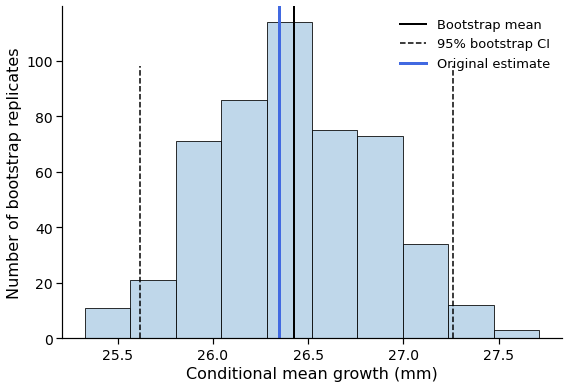

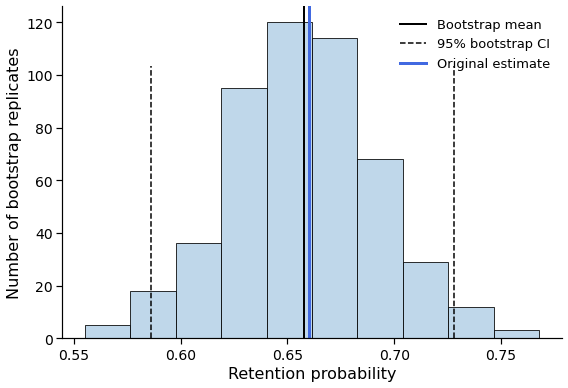

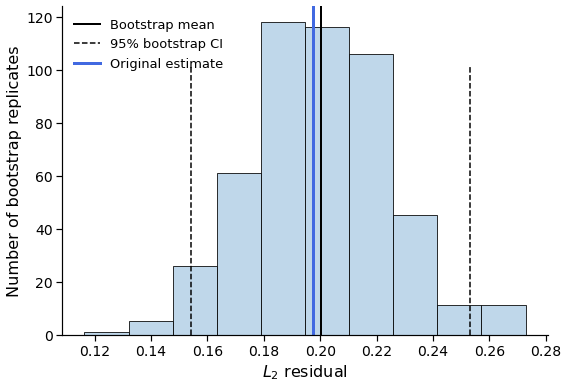

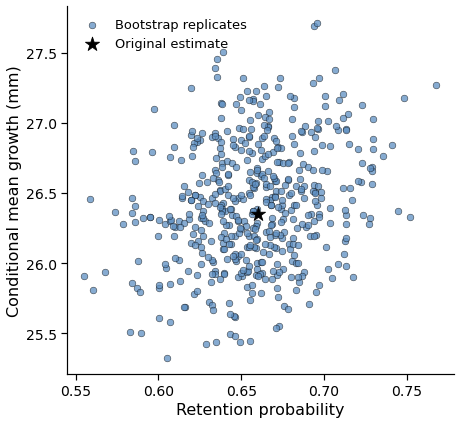

In [31]:
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS for a better plot
# ============================================================

LABEL_SIZE = 16
TICK_SIZE = 14
LEGEND_SIZE = 13

HIST_COLOR = "#BFD7EA"
POINT_COLOR = "#5E8FC2"

# ============================================================
# HELPER FUNCTION: HISTOGRAM WITH MEAN, CI, AND ORIGINAL VALUE
# ============================================================

def plot_bootstrap_histogram(
    data,
    original_value,
    xlabel,
    filename,
    bins=10
):
    
    # Plot a bootstrap histogram with its mean, percentile interval, and original non-bootstrap estimate.
    

    data = data.dropna()

    mean_val = data.mean()
    ci_low = data.quantile(0.025)
    ci_high = data.quantile(0.975)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    ax.hist(
        data,
        bins=bins,
        color=HIST_COLOR,
        edgecolor="black",
        linewidth=0.8
    )

    # Bootstrap mean
    ax.axvline(
        mean_val,
        color="black",
        linewidth=2,
        label="Bootstrap mean"
    )

    # 95% bootstrap CI
    ax.axvline(
        ci_low,
        color="black",
        linestyle="--",
        linewidth=1.5,
        ymin=0,
        ymax=0.82,
        label="95% bootstrap CI"
    )

    ax.axvline(
        ci_high,
        color="black",
        linestyle="--",
        linewidth=1.5,
        ymin=0,
        ymax=0.82
    )

    # Original estimate
    ax.axvline(
        original_value,
        color="royalblue",
        linewidth=3,
        label="Original estimate"
    )

    ax.set_xlabel(
        xlabel,
        fontsize=LABEL_SIZE
    )

    ax.set_ylabel(
        "Number of bootstrap replicates",
        fontsize=LABEL_SIZE
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_SIZE,
        width=1.2,
        length=6
    )

    ax.legend(
        fontsize=LEGEND_SIZE,
        frameon=False
    )

    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(False)

    fig.tight_layout()

    fig.savefig(
        filename,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# HISTOGRAM: CONDITIONAL MEAN GROWTH
# ============================================================

plot_bootstrap_histogram(
    data=boot_df["ConditionalMeanGrowth_mm"],
    original_value=original_growth,
    xlabel="Conditional mean growth (mm)",
    filename=f"bootstrap_growth_{BOOT_YEAR}.pdf",
    bins=10
)

# ============================================================
# HISTOGRAM: RETENTION
# ============================================================

plot_bootstrap_histogram(
    data=boot_df["Retention"],
    original_value=original_retention,
    xlabel="Retention probability",
    filename=f"bootstrap_retention_{BOOT_YEAR}.pdf",
    bins=10
)

# ============================================================
# HISTOGRAM: L2 RESIDUALS
# ============================================================

plot_bootstrap_histogram(
    data=boot_df["L2Residual"],
    original_value=residual_l2_original,
    xlabel=r"$L_2$ residual",
    filename=f"bootstrap_L2_residual_{BOOT_YEAR}.pdf",
    bins=10
)

# ============================================================
# SCATTERPLOT: RETENTION VS. GROWTH
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 6))

ax.scatter(
    boot_df["Retention"],
    boot_df["ConditionalMeanGrowth_mm"],
    s=45,
    color=POINT_COLOR,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.75,
    label="Bootstrap replicates"
)

ax.scatter(
    original_retention,
    original_growth,
    marker="*",
    s=220,
    color="black",
    edgecolor="black",
    linewidth=0.8,
    label="Original estimate",
    zorder=5
)

ax.set_xlabel(
    "Retention probability",
    fontsize=LABEL_SIZE
)

ax.set_ylabel(
    "Conditional mean growth (mm)",
    fontsize=LABEL_SIZE
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=TICK_SIZE,
    width=1.2,
    length=6
)

ax.legend(
    fontsize=LEGEND_SIZE,
    frameon=False
)

ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

fig.tight_layout()

fig.savefig(
    f"bootstrap_retention_vs_growth_{BOOT_YEAR}.pdf",
    bbox_inches="tight"
)

plt.show()